Bibliotekos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Pagrindinių komponentų analizė:

In [2]:
def PCA_Algorithm (data):
    sc = StandardScaler()
    data_scaled = sc.fit_transform(data)
    pca = PCA()
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

#### Pirmas duomenų rinkinys:

In [3]:
df_ellipsoid = pd.read_csv("ellipsoid.50d10c.8.txt", sep = '\t', header = None)
df_ellipsoid.head(5)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.006412,0.002997,-0.028828,-0.005403,0.070193,0.055493,-0.067224,-0.042464,0.040229,-0.027893,...,0.031264,0.051459,0.033878,0.050101,0.035105,-0.123535,-0.019261,0.052944,-0.070087,0.006853
1,0.101276,0.049836,0.058219,0.057525,0.052512,0.091341,-0.137052,0.034034,0.047139,-0.122298,...,0.027550,0.050529,0.110795,0.020408,-0.035099,-0.212835,0.001148,0.194039,-0.012406,0.027588
2,-0.025276,-0.024517,-0.058769,-0.007441,0.055704,0.048386,-0.026769,-0.059224,0.019099,0.020766,...,-0.018689,0.064856,0.028137,0.042149,0.060543,-0.085773,-0.024084,0.039798,-0.042798,-0.010927
3,0.087410,0.049991,0.050905,0.043360,0.051087,0.056953,-0.138113,0.020437,0.050432,-0.119749,...,0.029750,0.052365,0.092220,0.003401,0.003823,-0.201655,-0.026034,0.197960,-0.033710,0.001458
4,0.160108,0.064853,0.103496,0.080948,0.057654,0.114975,-0.193117,0.074163,0.066625,-0.203372,...,0.046991,0.037344,0.170901,0.009572,-0.071378,-0.276137,0.001418,0.267204,-0.022505,0.046585


In [4]:
print("Duomenų struktūra: ", df_ellipsoid.shape)

Duomenų struktūra:  (3140, 50)


In [5]:
transformed_ellipsoid, variance_ellipsoid = PCA_Algorithm(df_ellipsoid)
print("Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos:", variance_ellipsoid[:2])

Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos: [0.29704861 0.17209629]


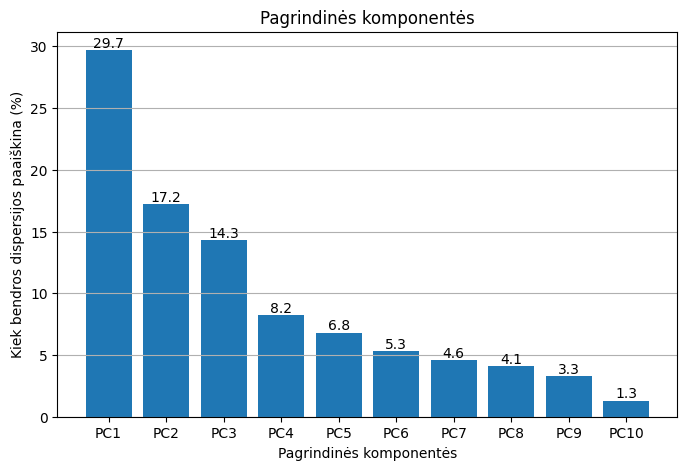

In [6]:
var_pca = np.round(variance_ellipsoid * 100, decimals = 1)
var_pca_10 = var_pca[:10]
labels = ["PC" + str(x) for x in range(1, len(var_pca_10) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(var_pca_10) + 1), height = var_pca_10, tick_label = labels)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

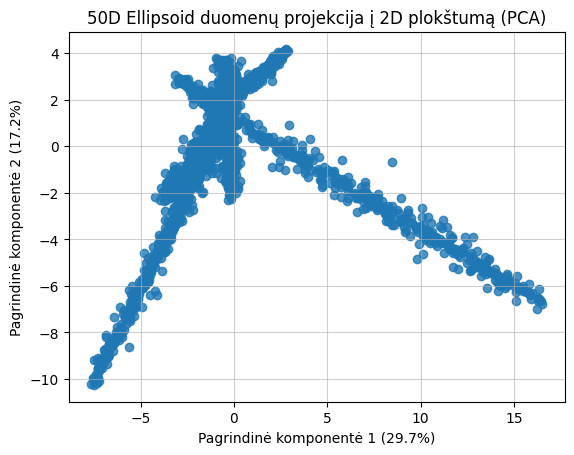

In [7]:
plt.grid(alpha=0.6)
plt.scatter(transformed_ellipsoid[:, 0], transformed_ellipsoid[:, 1], alpha=0.8)
plt.title("50D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)")
plt.xlabel(f"Pagrindinė komponentė 1 ({var_pca[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({var_pca[1]}%)")
plt.show()

#### Antras duomenų rinkinys:

In [8]:
df_iris = pd.read_csv("iris.txt", sep = '\t', header = None)
df_iris.head(5)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
print("Duomenų struktūra: ", df_iris.shape)

Duomenų struktūra:  (150, 4)


In [10]:
transformed_iris, variance_iris = PCA_Algorithm(df_iris)
print("Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos:", variance_iris[:2])

Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos: [0.72770452 0.23030523]


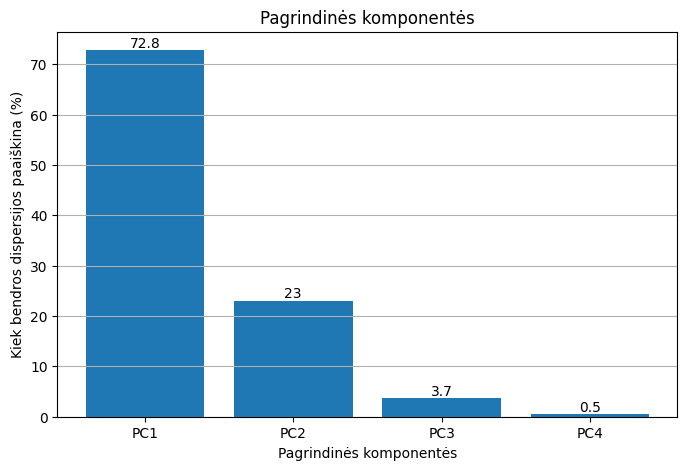

In [11]:
var_pca = np.round(variance_iris * 100, decimals = 1)
labels = ["PC" + str(x) for x in range(1, len(var_pca) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(var_pca) + 1), height = var_pca, tick_label = labels)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

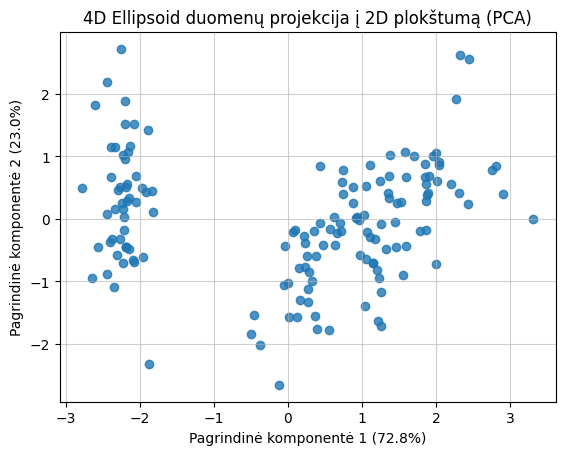

In [12]:
plt.grid(alpha=0.6)
plt.scatter(transformed_iris[:, 0], transformed_iris[:, 1], alpha=0.8)
plt.title("4D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)")
plt.xlabel(f"Pagrindinė komponentė 1 ({var_pca[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({var_pca[1]}%)")
plt.show()

#### Trečias duomenų rinkinys:

In [13]:
df_train = pd.read_csv("mnist_train.csv", sep = ',')
df_train.head(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
print("Duomenų struktūra: ", df_train.shape)

Duomenų struktūra:  (60000, 785)


In [15]:
transformed_train, variance_train = PCA_Algorithm(df_train)
print("Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos:", variance_train[:2])

Dvi pagrindinės komponentės, kurios paaiškina didžiausią kiekį dispersijos: [0.05650225 0.04080865]


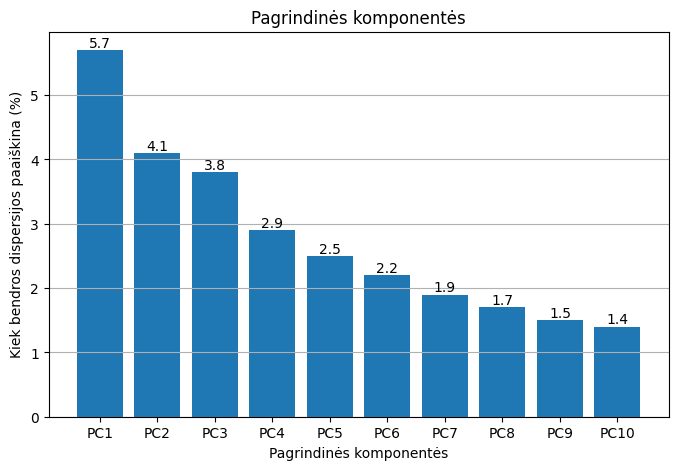

In [16]:
var_pca = np.round(variance_train * 100, decimals = 1)
var_pca_10 = var_pca[:10]
labels = ["PC" + str(x) for x in range(1, len(var_pca_10) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(var_pca_10) + 1), height = var_pca_10, tick_label = labels)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

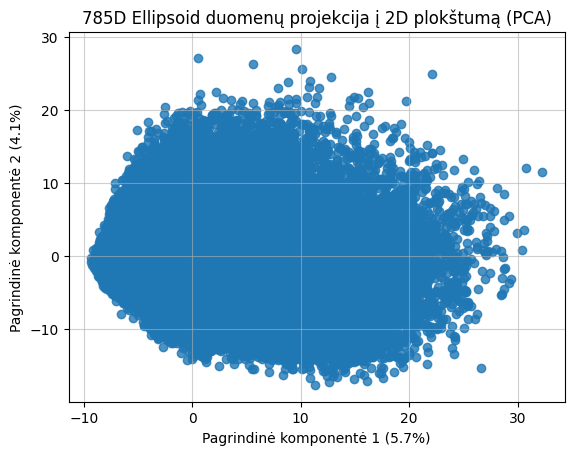

In [17]:
plt.grid(alpha=0.6)
plt.scatter(transformed_train[:, 0], transformed_train[:, 1], alpha=0.8)
plt.title("785D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)")
plt.xlabel(f"Pagrindinė komponentė 1 ({var_pca[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({var_pca[1]}%)")
plt.show()

#### Ketvirtas duomenų rinkinys:

In [18]:
df_roll = pd.read_csv("swiss_roll_example.csv", sep = ';', header = None)
df_roll.head(5)

,0,1,2
0,12.2009,8.8806,-2.1622
1,10.2780,1.9788,8.3610
2,5.5008,12.5690,-2.1587
3,9.7068,9.8894,9.1226
4,-3.3909,14.6149,-10.1192


In [19]:
print("Duomenų struktūra: ", df_roll.shape)

Duomenų struktūra:  (400, 3)


In [20]:
transformed_roll, variance_roll = PCA_Algorithm(df_roll)
print("Dvi pagrindinės komponentės, kurio paaiškina didžiausią kiekį dispersijos:", variance_roll[:2])

Dvi pagrindinės komponentės, kurio paaiškina didžiausią kiekį dispersijos: [0.36681561 0.33478653]


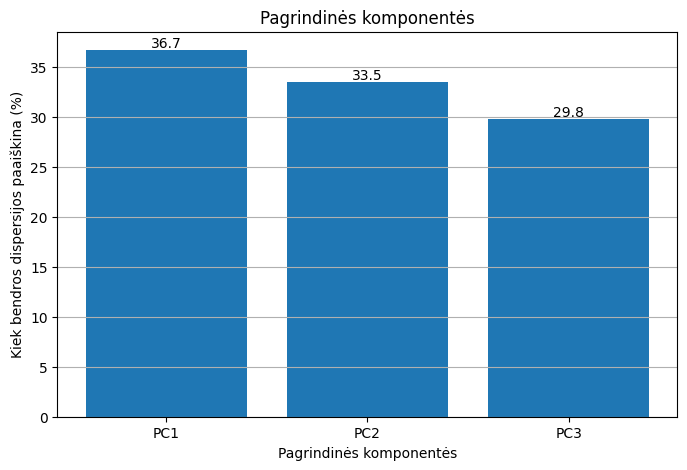

In [21]:
var_pca = np.round(variance_roll * 100, decimals = 1)
labels = ["PC" + str(x) for x in range(1, len(var_pca) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(var_pca) + 1), height = var_pca, tick_label = labels)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

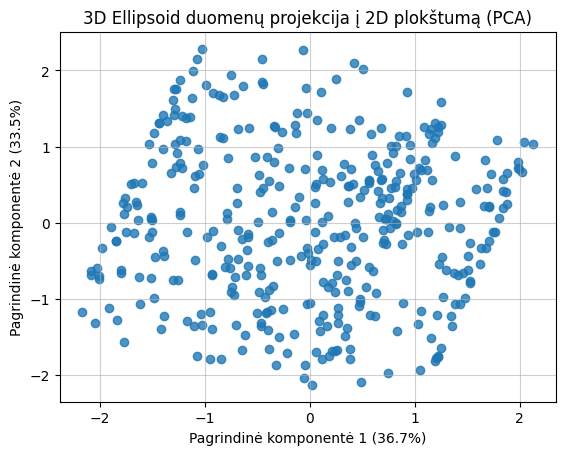

In [22]:
plt.grid(alpha=0.6)
plt.scatter(transformed_roll[:, 0], transformed_roll[:, 1], alpha=0.8)
plt.title("3D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)")
plt.xlabel(f"Pagrindinė komponentė 1 ({var_pca[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({var_pca[1]}%)")
plt.show()

-----

Šaltiniai:
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html